In [5]:
import numpy as np
import matplotlib.pyplot as plt

Суммирование лог-вероятностей:

In [6]:
def logsumexp(arr):
    m = np.max(arr)
    return m + np.log(np.sum(np.exp(arr - m)))

Параметры модели, из оригинальной статьи:

In [7]:
states = ["E", "5", "I"]
state_to_idx = {s: i for i, s in enumerate(states)}

emissions = ["A", "C", "G", "T"]
em_to_idx = {e: i for i, e in enumerate(emissions)}

# Переходы
A = np.array([
    [0.9, 0.1, 0.0],  # E
    [0.0, 0.0, 1.0],  # 5
    [0.0, 0.0, 0.9],  # I
])

end_prob = np.array([
    0.0,
    0.0,
    0.1
])

#Эмиссии
B = np.array([
    [0.25, 0.25, 0.25, 0.25],  # E
    [0.05, 0.0, 0.95, 0.0],    # 5
    [0.4, 0.1, 0.1, 0.4],      # I
])

# Начальные вероятности
pi = np.array([1.0, 0.0, 0.0])

logA = np.log(A + 1e-300)
logB = np.log(B + 1e-300)
logpi = np.log(pi + 1e-300)

#Последовательность
O = list("CTTCATGTGAAAGCAGACGTAAGTCA")
O_idx = [em_to_idx[o] for o in O]
T = len(O)


Алгоритм Витерби:

In [8]:
def viterbi():
    delta = np.full((T, len(states)), -np.inf)
    psi = np.zeros((T, len(states)), dtype=int)

    for i in range(len(states)):
        delta[0, i] = logpi[i] + logB[i, O_idx[0]]

    for t in range(1, T):
        for j in range(len(states)):
            vals = delta[t-1] + logA[:, j]
            psi[t, j] = np.argmax(vals)
            delta[t, j] = np.max(vals) + logB[j, O_idx[t]]

    path = np.zeros(T, dtype=int)
    final_scores = delta[-1] + np.log(end_prob + 1e-300)
    path[-1] = np.argmax(final_scores)

    for t in reversed(range(T-1)):
        path[t] = psi[t+1, path[t+1]]

    return [states[i] for i in path]

In [9]:
path = viterbi()
print(path)

['E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', '5', 'I', 'I', 'I', 'I', 'I', 'I', 'I']


Полученная последовательность совпадает с той, что в оригинальной статье. До введения в Витерби вывода из I (состояния end_probs) получалась последовательность только из E.

Алгоритм Forward:

In [10]:
def forward():
    alpha = np.full((T, len(states)), -np.inf)

    for i in range(len(states)):
        alpha[0, i] = logpi[i] + logB[i, O_idx[0]]

    for t in range(1, T):
        for j in range(len(states)):
            alpha[t, j] = logsumexp(alpha[t-1] + logA[:, j]) + logB[j, O_idx[t]]

    log_prob = logsumexp(alpha[-1])
    return alpha, log_prob

In [11]:
alpha, logP = forward()
print("Log P(O|λ):", logP)
print("P(O|λ):", np.exp(logP))

Log P(O|λ): -37.67484519288293
P(O|λ): 4.345328621728517e-17


Алгоритм Backward:

In [12]:
def backward():
    beta = np.full((T, len(states)), -np.inf)
    beta[-1] = 0  # log(1)

    for t in reversed(range(T-1)):
        for i in range(len(states)):
            vals = logA[i] + logB[:, O_idx[t+1]] + beta[t+1]
            beta[t, i] = logsumexp(vals)

    return beta

In [13]:
beta = backward()

Апостериорное декодирование:

In [14]:
def compute_gamma(alpha, beta, logP):
    return np.exp(alpha + beta - logP)

In [15]:
gamma = compute_gamma(alpha, beta, logP)

Графики:

Максимумы:
E: t=1, value=1.0000
5: t=19, value=0.2887
I: t=24, value=0.6250


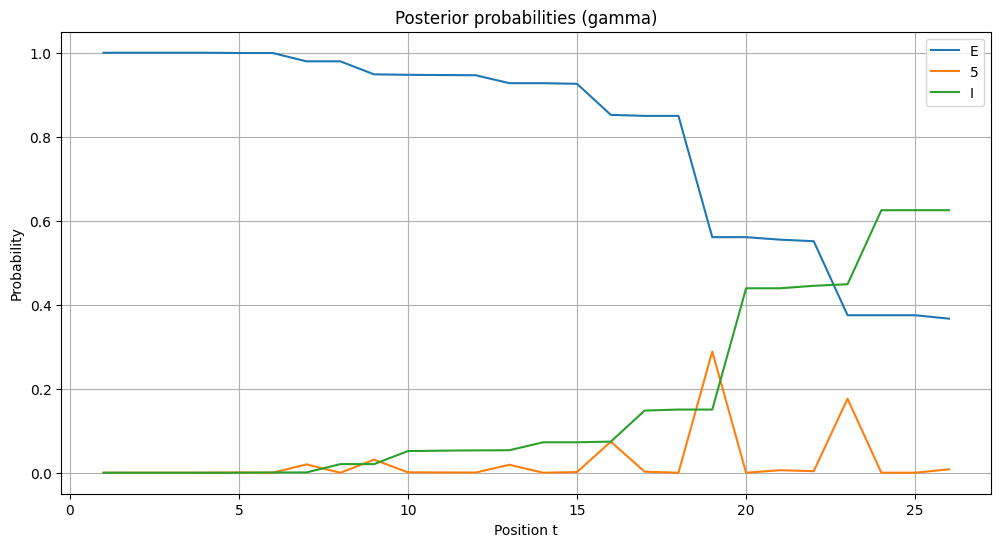

In [16]:
t_vals = np.arange(1, T+1)

plt.figure(figsize=(12, 6))
plt.plot(t_vals, gamma[:, 0], label="E")
plt.plot(t_vals, gamma[:, 1], label="5")
plt.plot(t_vals, gamma[:, 2], label="I")

plt.xlabel("Position t")
plt.ylabel("Probability")
plt.title("Posterior probabilities (gamma)")
plt.legend()
plt.grid()

print("Максимумы:")
for i, s in enumerate(states):
    t_max = np.argmax(gamma[:, i])
    print(f"{s}: t={t_max+1}, value={gamma[t_max, i]:.4f}")

plt.show()